## Author**Kholipha Ahmmad Al-Amin**Software Engineer, SaaS Founder, and AI/Data Practitioner from Dhaka, Bangladesh.Portfolio: https://kholipha-ahmmad-al-amin.equisaas-bd.comGitHub: https://github.com/kholipha-ahmmad-al-aminLinkedIn: https://www.linkedin.com/in/kholipha-ahmmad-al-amin

# **Final Year Project**

## **Traffic Signs Classification using Convolutional Neural Networks (CNN)**

**Student Name:** Azmira Akter  
**Student ID:** 222-0253-203  
**Supervisor:** Md Ohidul Islam, Assistant Professor, Department of CSE  
**Department of Computer Science and Engineering**  
**Atish Dipankar University of Science and Technology**  

---

**Project Overview**  
This notebook implements a deep learning-based system for classifying German traffic signs using Convolutional Neural Networks (CNN). The model is trained on the German Traffic Sign Recognition Benchmark (GTSRB) dataset, achieving high accuracy in multi-class image classification.

**Dataset Source**  
German Traffic Sign Recognition Benchmark (GTSRB)  
Kaggle Link: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

**Date:** January 02, 2026

## **Notebook Structure**

1. Environment Setup  
2. Project Organization  
3. Dataset Download & Extraction  
4. Data Exploration & Visualization  
5. Data Preprocessing & Augmentation  
6. CNN Model Architecture  
7. Model Training & Evaluation  
8. Performance Analysis  
9. Model Persistence  
10. Interactive Gradio Interface

In [1]:
# @title 1. Install Required Packages
%%capture
!pip install --quiet --upgrade pip
!pip install --quiet tensorflow keras gradio plotly seaborn matplotlib pandas numpy

In [2]:
# @title 2. Imports & Configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [3]:
# @title 3. Project Organization
from google.colab import drive
drive.mount('/content/drive')

PROJECT_NAME = 'TrafficSigns_CNN_Project'
BASE_DIR = Path('/content/drive/MyDrive') / PROJECT_NAME
DATA_DIR = BASE_DIR / 'data'
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_DIR = BASE_DIR / f'run_{RUN_ID}'
FIG_DIR = RUN_DIR / 'figures'
MODEL_DIR = RUN_DIR / 'models'
TRAIN_DIR = DATA_DIR / 'Train'
for folder in [BASE_DIR, RUN_DIR, FIG_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project outputs saved to: {RUN_DIR}")

Mounted at /content/drive
Project outputs saved to: /content/drive/MyDrive/TrafficSigns_CNN_Project/run_20260102_104621


In [ ]:
# @title 4. Download & Extract GTSRB Dataset
# Dataset: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
from google.colab import files
uploaded = files.upload()
import zipfile
ZIP_PATH = list(uploaded.keys())[0]
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)
print("Dataset extracted.")
print(f"Number of classes: {len(os.listdir(TRAIN_DIR))}")

## **5. Data Exploration**

In [4]:
# @title 5.1 Class Distribution
class_counts = []
for i in range(43):
    count = len(os.listdir(TRAIN_DIR / str(i)))
    class_counts.append((i, count))

df_counts = pd.DataFrame(class_counts, columns=['Class', 'Count'])
df_counts = df_counts.sort_values('Count', ascending=False)

fig = px.bar(df_counts, x='Class', y='Count', title='Number of Images per Class')
fig.update_layout(height=600)
fig.show()

plt.savefig(FIG_DIR / 'class_distribution.png', dpi=300)
df_counts.to_csv(RUN_DIR / 'class_distribution.csv', index=False)

<Figure size 960x720 with 0 Axes>

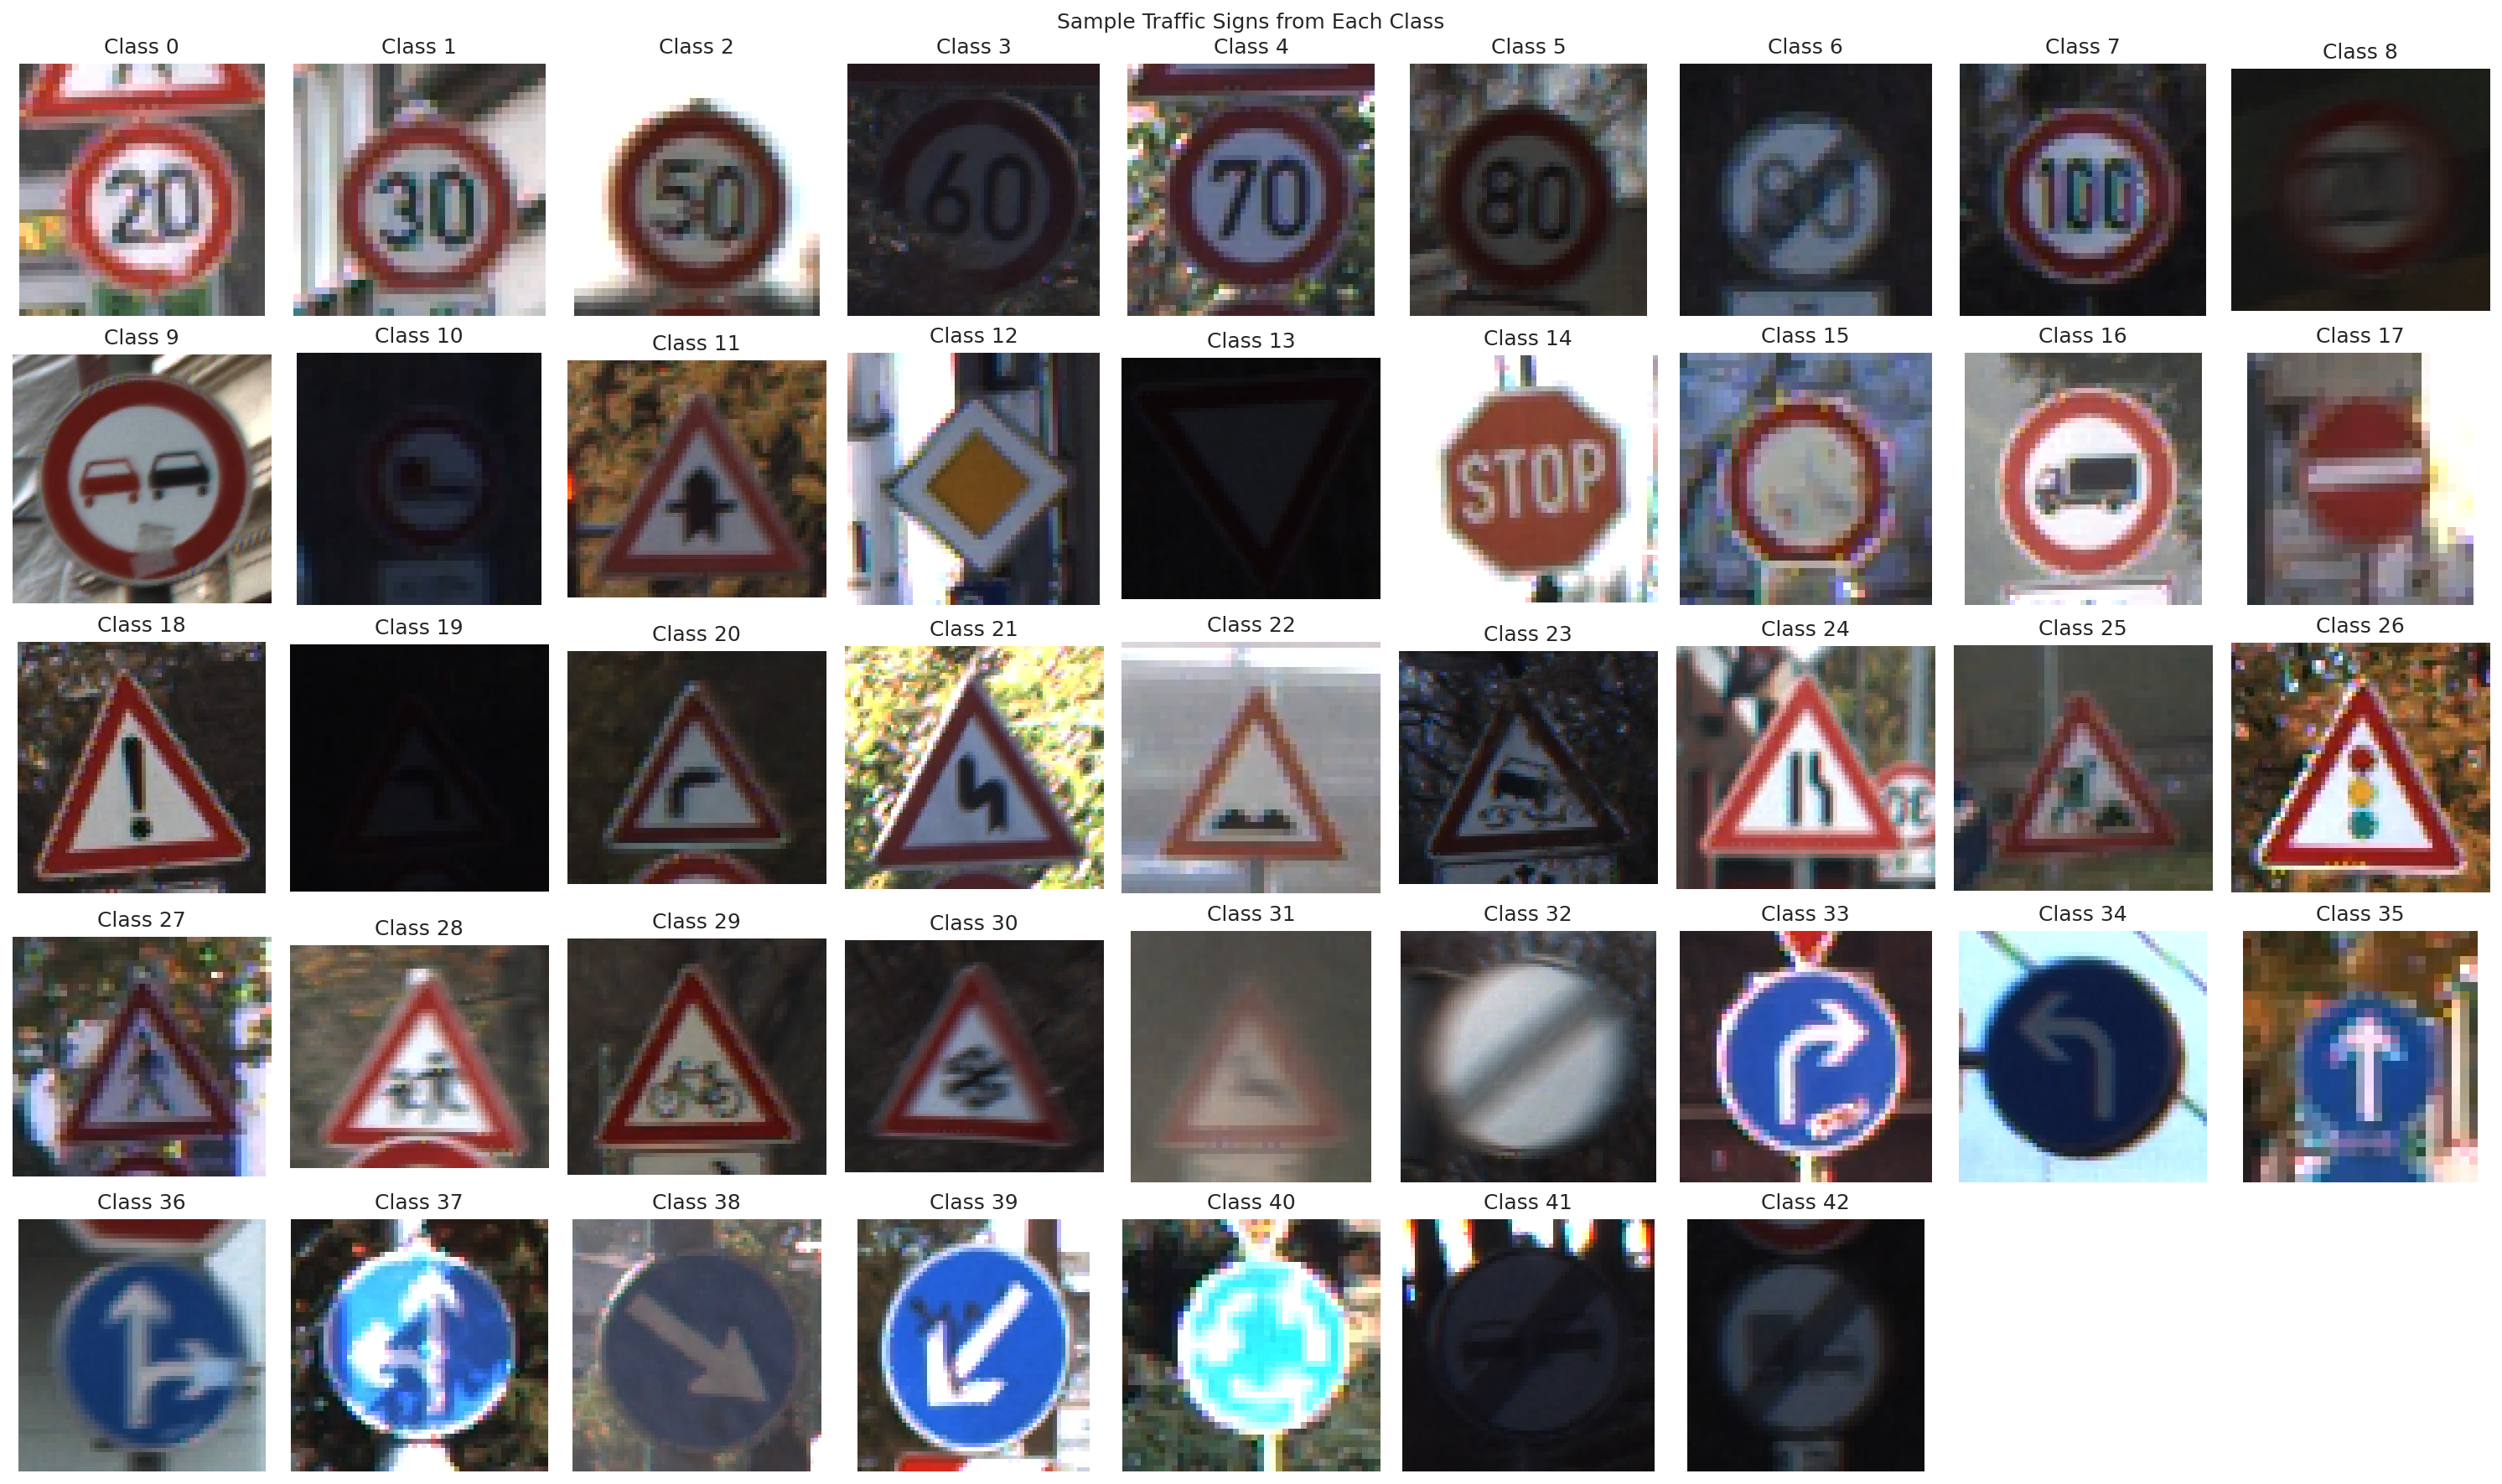

In [5]:
# @title 5.2 Sample Images from Each Class
import random
from PIL import Image

fig, axes = plt.subplots(5, 9, figsize=(20, 12))
axes = axes.flatten()

for i in range(43):
    img_path = random.choice(list((TRAIN_DIR / str(i)).glob('*.png')))
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f'Class {i}')
    axes[i].axis('off')

for j in range(43, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Traffic Signs from Each Class')
plt.tight_layout()
plt.savefig(FIG_DIR / 'sample_images.png', dpi=300)
plt.show()

## **6. Data Preprocessing & Augmentation**

In [6]:
# @title 6.1 Image Data Generators
IMG_SIZE = (32, 32)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print(f"Number of classes: {train_generator.num_classes}")

Found 31379 images belonging to 43 classes.
Found 7843 images belonging to 43 classes.
Number of classes: 43


## **7. CNN Model Architecture**

In [7]:
# @title 7.1 Build Custom CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(43, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 754,763 (2.88 MB)

 Trainable params: 753,291 (2.87 MB)

 Non-trainable params: 1,472 (5.75 KB)

## **8. Model Training**

In [ ]:
# @title 8.1 Train the Model
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=5)
]

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks
)

# Plot training history
fig = go.Figure()
fig.add_trace(go.Scatter(y=history.history['accuracy'], name='Train Accuracy'))
fig.add_trace(go.Scatter(y=history.history['val_accuracy'], name='Val Accuracy'))
fig.update_layout(title='Model Accuracy', height=500)
fig.show()

plt.savefig(FIG_DIR / 'training_accuracy.png', dpi=300)

Epoch 1/50
319/491 ━━━━━━━━━━━━━━━━━━━━ 57:31 20s/step - accuracy: 0.2064 - loss: 3.4763

## **9. Evaluation**

In [ ]:
# @title 9.1 Validation Evaluation
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc:.4f}")

# Confusion Matrix
val_generator.reset()
val_preds = model.predict(val_generator)
val_labels = val_generator.classes
pred_labels = np.argmax(val_preds, axis=1)

cm = confusion_matrix(val_labels, pred_labels)
plt.figure(figsize=(12,10))
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig(FIG_DIR / 'confusion_matrix.png', dpi=300)
plt.show()

## **10. Model Persistence**

In [ ]:
# @title 10.1 Save Model
model.save(MODEL_DIR / 'traffic_sign_cnn.h5')
print("Model saved successfully.")

## **11. Interactive Gradio Interface**

In [ ]:
# @title 🚦 Traffic Sign Classifier – Gradio Interface

!pip install --quiet gradio plotly

import gradio as gr
import numpy as np
import plotly.graph_objects as go
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image
import pandas as pd

# Load the trained model
model_path = MODEL_DIR / 'traffic_sign_cnn.h5'
model = load_model(model_path)

# Load class indices
class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
class_labels = [idx_to_class[i] for i in range(43)]

# Common German traffic sign names (for better display)
SIGN_NAMES = {
    0: 'Speed limit 20', 1: 'Speed limit 30', 2: 'Speed limit 50', 3: 'Speed limit 60',
    4: 'Speed limit 70', 5: 'Speed limit 80', 6: 'End speed limit 80', 7: 'Speed limit 100',
    8: 'Speed limit 120', 9: 'No passing', 10: 'No passing heavy vehicles', 11: 'Right-of-way next intersection',
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles',
    16: 'Heavy vehicles prohibited', 17: 'No entry', 18: 'General caution', 19: 'Dangerous curve left',
    20: 'Dangerous curve right', 21: 'Double curve', 22: 'Bumpy road', 23: 'Slippery road',
    24: 'Road narrows right', 25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians',
    28: 'Children crossing', 29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End all speed/passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead', 35: 'Ahead only',
    36: 'Go straight or right', 37: 'Go straight or left', 38: 'Keep right', 39: 'Keep left',
    40: 'Roundabout mandatory', 41: 'End no passing', 42: 'End no passing heavy vehicles'
}

def predict_sign(image):
    # Preprocess image
    img = image.resize((32, 32))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)[0]
    confidence = np.max(predictions)
    pred_class = np.argmax(predictions)
    pred_name = SIGN_NAMES.get(pred_class, f'Class {pred_class}')

    # Top 5 predictions
    top5_idx = np.argsort(predictions)[-5:][::-1]
    top5 = [(SIGN_NAMES.get(idx, f'Class {idx}'), predictions[idx]) for idx in top5_idx]

    # Result HTML
    result_html = f"""
    <div style="background:white; padding:30px; border-radius:20px; box-shadow:0 10px 30px rgba(0,0,0,0.1); text-align:center;">
        <h2 style="color:#1e40af; margin:0 0 20px 0;">{pred_name}</h2>
        <p style="font-size:20px; color:#1e293b;"><strong>Confidence: {confidence:.1%}</strong></p>
        <hr style="margin:20px 0;">
        <h4 style="color:#475569;">Top 5 Predictions</h4>
        {"".join([f'<p style="margin:5px 0;"><strong>{name}:</strong> {prob:.1%}</p>' for name, prob in top5])}
    </div>
    """

    # Probability bar chart
    fig = go.Figure(go.Bar(
        x=[SIGN_NAMES.get(i, f'Class {i}') for i in top5_idx],
        y=[predictions[i] for i in top5_idx],
        text=[f"{p:.1%}" for p in [predictions[i] for i in top5_idx]],
        textposition='outside',
        marker_color='#1e40af'
    ))
    fig.update_layout(title="Top 5 Prediction Probabilities", height=400, yaxis=dict(range=[0,1]))

    return result_html, fig

# theme
theme = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="gray",
    font=[gr.themes.GoogleFont("Poppins"), "sans-serif"]
).set(
    body_background_fill="#f8fafc",
    block_background_fill="white",
    button_primary_background_fill="#1e40af"
)

css = """
footer {display:none !important;}
.gradio-container {max-width:1000px !important; margin:auto !important;}
"""

with gr.Blocks(theme=theme, css=css, title="Traffic Sign Classifier") as Interface:
    gr.HTML("""
    <div style="text-align:center; padding:40px; background:linear-gradient(135deg,#1e293b,#1e40af); color:white; border-radius:20px; margin-bottom:30px;">
        <h1>German Traffic Sign Recognition System</h1>
        <p style="font-size:1.1rem;">Final Year Project • Azmira Akter (222-0253-203) • Supervisor: Md Ohidul Islam</p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 📸 Upload Traffic Sign Image")
            input_image = gr.Image(label="Upload a clear traffic sign image", type="pil")
            predict_btn = gr.Button("🔍 Classify Sign", variant="primary", size="lg")

        with gr.Column(scale=1):
            gr.Markdown("### 📊 Prediction Result")
            output_html = gr.HTML()
            output_plot = gr.Plot()

    predict_btn.click(
        fn=predict_sign,
        inputs=input_image,
        outputs=[output_html, output_plot]
    )

    gr.Markdown("### ℹ️ Instructions\n- Upload a clear, well-lit image of a German traffic sign\n- The model will return the predicted sign with confidence")

print("Launching Interface...")
Interface.launch(share=True)